In [1]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np

from utils.dataset import load_dataset_v2, create_lstm_dataset
from tqdm.notebook import tqdm

In [2]:
model = ort.InferenceSession('lstm_model.onnx')

In [3]:
file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

start_time = time.strftime('%Y%m%d-%H%M%S', time.localtime(time.time()))

dataset = load_dataset_v2(file_path_list)
time_dt_arr = np.concatenate([np.array([0]), np.diff(dataset['time(s)'].to_numpy())])
dataset = pd.concat([pd.DataFrame(time_dt_arr, columns=['time_diff(s)']), dataset], axis=1)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [4]:
extra_column_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
extra_feature = pd.DataFrame()

for col_name in extra_column_name_list:
    extra_feature['diff_'+col_name] = np.diff(dataset[col_name].to_numpy())

dataset = pd.concat([dataset, extra_feature], axis=1)

In [5]:
dataset = dataset[dataset['outlet_flowrate(lpm)'] > 1]
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)
dataset.shape

(196560, 21)

In [6]:
feature_col_name_list = ['pressure_1(bar)', 'main_pressure(bar)', 'diff_pressure_1(bar)', 'diff_main_pressure(bar)']
#feature_col_name_list = ['time_diff(s)', 'pressure_1(bar)', 'main_pressure(bar)']

target_col_name = 'outlet_flowrate(lpm)'

train_data = dataset[dataset['test_case_iter']!=3]
val_data = dataset[dataset['test_case_iter']==3]

train_feature = train_data[feature_col_name_list]
train_feature.reset_index(drop=True, inplace=True)

train_target = pd.DataFrame(train_data[target_col_name])
train_target.reset_index(drop=True, inplace=True)

val_feature = val_data[feature_col_name_list]
val_feature.reset_index(drop=True, inplace=True)

val_target = pd.DataFrame(val_data[target_col_name])
val_target.reset_index(drop=True, inplace=True)

In [7]:
seq_len = 30
pred_distance = 0

train_feature, train_target = create_lstm_dataset(train_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len,
                                                  pred_distance=pred_distance, target_idx_pos=4)
val_feature, val_target = create_lstm_dataset(val_data[feature_col_name_list+[target_col_name]].to_numpy(), seq_len=seq_len,
                                              pred_distance=pred_distance, target_idx_pos=4)

In [8]:
train_feature = train_feature.astype(np.float32)
train_target = train_target.astype(np.float32)

time_list = []
train_pred = []

for input_data in tqdm(train_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    train_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/132531 [00:00<?, ?it/s]

Average inference time per data sequence: 0.240 mile seconds


In [9]:
val_feature = val_feature.astype(np.float32)
val_target = val_target.astype(np.float32)

time_list = []
val_pred = []

for input_data in tqdm(val_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    val_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/63971 [00:00<?, ?it/s]

Average inference time per data sequence: 0.236 mile seconds


In [10]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error

In [13]:
print(r2_score(train_target, train_pred), r2_score(val_target, val_pred))


0.9669469594955444 0.9462805390357971


In [16]:
print(mean_absolute_error(train_target, train_pred), mean_absolute_error(val_target, val_pred))


59.29885482788086 75.17407989501953


In [17]:
print(mean_absolute_percentage_error(train_target, train_pred), mean_absolute_percentage_error(val_target, val_pred))


0.1389555186033249 0.23388995230197906


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
data = val_data.iloc[seq_len-1:]
data.reset_index(drop=True, inplace=True)
data = pd.concat([data, pd.DataFrame({'pred_outlet_flowrate(lpm)': val_pred})], axis=1)

abs_error = np.abs(data['outlet_flowrate(lpm)'].to_numpy()-data['pred_outlet_flowrate(lpm)'].to_numpy())
rela_error = (abs_error / data['outlet_flowrate(lpm)'].to_numpy())*100

val_data_slice =  pd.concat([data, pd.DataFrame({'abs_error': abs_error,'relative_error': rela_error})], axis=1)

In [76]:
val_data_slice.head()

,time_diff(s),time(s),pressure_1(bar),main_pressure(bar),venturi_pressure_1(bar),venturi_pressure_2(bar),venturi_pressure_3(bar),venturi_pressure_4(bar),venturi_pressure_5(bar),pump_speed(rpm),...,test_case,test_case_iter,nozzle_len(mm),nozzle_dia(mm),venturi_dist(mm),diff_pressure_1(bar),diff_main_pressure(bar),pred_outlet_flowrate(lpm),abs_error,relative_error
0,0.01,47.07,-0.20,7.38,7.40,0.00,0.04,-0.02,0.09,904.36,...,1.0,3.0,12.0,12.0,0.0,0.10,0.00,1115.874878,479.534878,75.358280
1,0.01,47.17,-0.14,7.22,7.53,0.08,0.08,0.01,0.02,887.81,...,1.0,3.0,12.0,12.0,0.0,0.04,-0.01,1104.909912,462.139912,71.898177
2,0.01,47.27,-0.07,7.58,7.53,0.02,-0.01,-0.06,-0.00,882.19,...,1.0,3.0,12.0,12.0,0.0,0.04,-0.01,1102.292847,446.982847,68.209374
3,0.01,47.37,-0.18,7.19,7.42,-0.00,0.03,0.12,0.23,900.27,...,1.0,3.0,12.0,12.0,0.0,0.08,-0.01,1089.168213,425.158213,64.028887
4,0.01,47.47,-0.15,7.32,7.46,0.09,0.07,0.01,-0.00,891.20,...,1.0,3.0,12.0,12.0,0.0,0.05,-0.01,1065.899048,383.599048,56.221464


Text(0, 0.5, 'Relative error (%)')

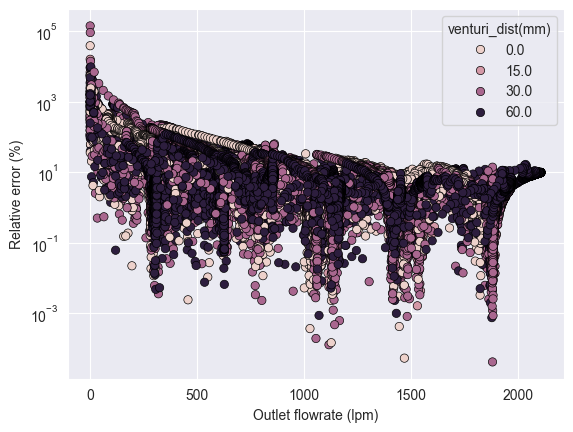

In [77]:
sns.scatterplot(data=val_data_slice, x='outlet_flowrate(lpm)', y='relative_error', hue='venturi_dist(mm)', edgecolor='black')

plt.xlabel('Outlet flowrate (lpm)')

plt.yscale('log')
plt.ylabel('Relative error (%)')

In [78]:
pump_speed_1_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 850) & (val_data_slice['pump_speed(rpm)'] < 950)]
pump_speed_1_df.reset_index(drop=True, inplace=True)
pump_speed_1_df_fix = pump_speed_1_df.copy()
pump_speed_1_df_fix['pump_speed(rpm)'] = 900

pump_speed_2_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 1150) & (val_data_slice['pump_speed(rpm)'] < 1250)]
pump_speed_2_df.reset_index(drop=True, inplace=True)
pump_speed_2_df_fix = pump_speed_2_df.copy()
pump_speed_2_df_fix['pump_speed(rpm)'] = 1200

pump_speed_3_df = val_data_slice[(val_data_slice['pump_speed(rpm)'] > 1450) & (val_data_slice['pump_speed(rpm)'] < 1550)]
pump_speed_3_df.reset_index(drop=True, inplace=True)
pump_speed_3_df_fix = pump_speed_3_df.copy()
pump_speed_3_df_fix['pump_speed(rpm)'] = 1500

pump_speed_df = pd.concat([pump_speed_1_df_fix, pump_speed_2_df_fix, pump_speed_3_df_fix])

In [79]:
stats = pump_speed_1_df_fix[['relative_error', 'abs_error']].describe()
stats

,relative_error,abs_error
count,23881.000000,23881.000000
mean,37.420856,107.053666
std,1094.553876,107.180536
min,0.000129,0.001436
25%,4.581133,25.048079
50%,13.198765,72.246162
75%,31.595427,158.784976
max,141195.419825,1426.073740


Text(0, 0.5, 'Relative Error(%)')

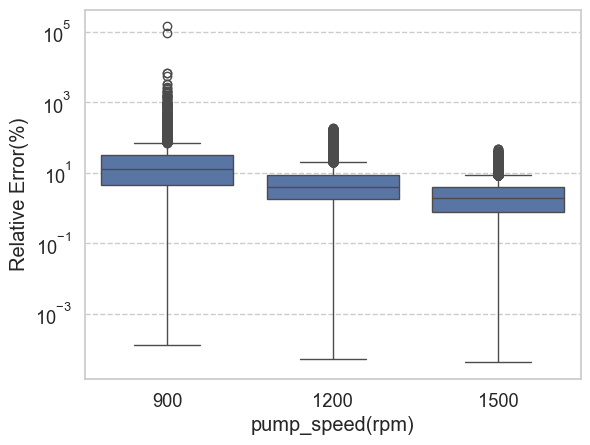

In [81]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='pump_speed(rpm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

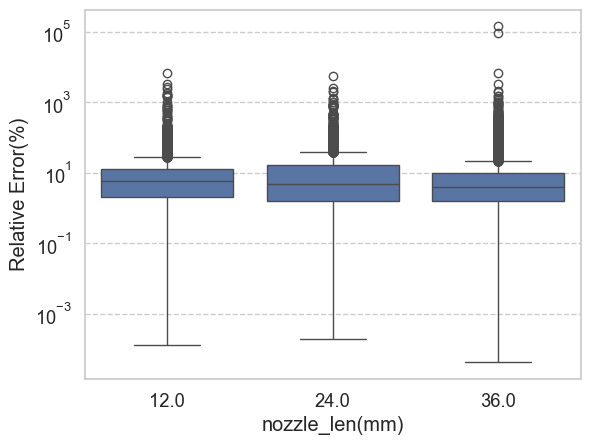

In [82]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='nozzle_len(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

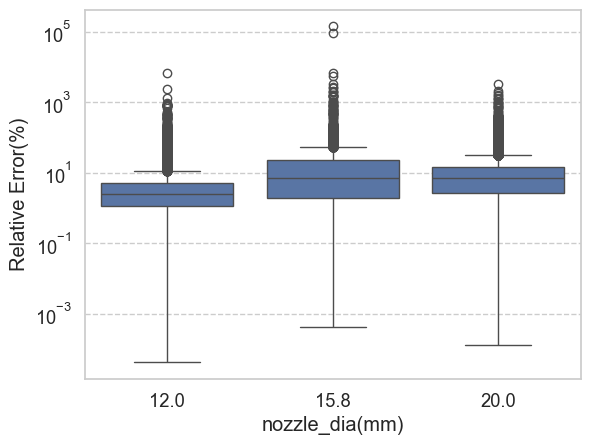

In [83]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='nozzle_dia(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

Text(0, 0.5, 'Relative Error(%)')

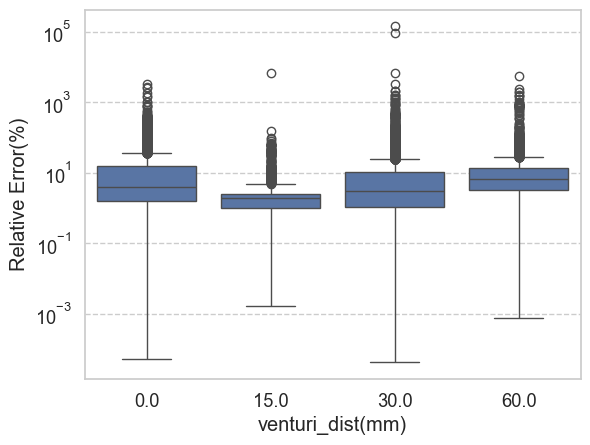

In [84]:
sns.set_theme(font_scale=1.2)
sns.set_style("whitegrid", {'grid.linestyle': '--'})

sns.boxplot(data=pump_speed_df, x='venturi_dist(mm)', y='relative_error')

plt.yscale('log')
plt.ylabel('Relative Error(%)')

<Axes: >

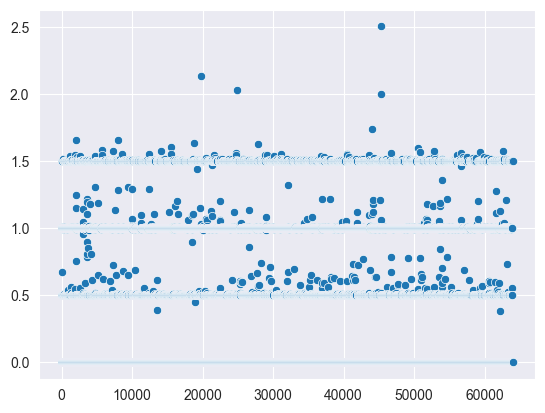

In [21]:
sns.scatterplot(np.array(time_list)*1000)

#plt.ylim(0, 5)